## Real -Time Ferry Tickets Sales & Redemption Analystics for Toronto Island Ferry Tickets

### importing the files and library 

In [43]:
import pandas as pd
import numpy as np
df = pd.read_csv('Toronto Island Ferry Tickets (1).csv')

### Display the csv data in head, tail 

In [44]:
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [45]:
df.tail()
### Display the information of the data 


,_id,Timestamp,Redemption Count,Sales Count
261533,261534,2015-05-04T16:00:00,0,2
261534,261535,2015-05-01T16:00:00,1,0
261535,261536,2015-05-01T15:45:00,0,1
261536,261537,2015-05-01T15:15:00,0,2
261537,261538,2015-05-01T13:30:00,0,1


In [46]:
### Display the information of the data 

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [47]:
### Display the description of the data 
df.describe()

,_id,Redemption Count,Sales Count
count,261538.000000,261538.000000,261538.000000
mean,130769.500000,48.885030,49.599106
std,75499.661689,104.549336,99.862285
min,1.000000,0.000000,0.000000
25%,65385.250000,3.000000,3.000000
50%,130769.500000,11.000000,13.000000
75%,196153.750000,40.000000,48.000000
max,261538.000000,7216.000000,7229.000000


In [48]:
### Display the shape of the data 
df.shape

(261538, 4)

# DATA INGESTION 

## Data cleaning and checking duplicates 

In [49]:
df.isnull().sum()


_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [50]:
df.duplicated().sum()


np.int64(0)

In [51]:
df.drop_duplicates(inplace=True)
df


,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0
...,...,...,...,...
261533,261534,2015-05-04T16:00:00,0,2
261534,261535,2015-05-01T16:00:00,1,0
261535,261536,2015-05-01T15:45:00,0,1
261536,261537,2015-05-01T15:15:00,0,2


In [52]:
df.isnull().sum()


_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [53]:
df.duplicated().sum()


np.int64(0)

In [54]:
df.drop_duplicates(inplace=True)
df.head(5)


,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


### Convert timestamp into datatime 

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   _id               261538 non-null  int64 
 1   Timestamp         261538 non-null  object
 2   Redemption Count  261538 non-null  int64 
 3   Sales Count       261538 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 8.0+ MB


In [56]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [57]:
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21 22:30:00,14,16
1,2,2025-12-21 22:15:00,1,0
2,3,2025-12-21 22:00:00,2,0
3,4,2025-12-21 21:30:00,11,1
4,5,2025-12-21 21:15:00,10,0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   _id               261538 non-null  int64         
 1   Timestamp         261538 non-null  datetime64[ns]
 2   Redemption Count  261538 non-null  int64         
 3   Sales Count       261538 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 8.0 MB


In [59]:
df['year'] = df['Timestamp'].dt.year
df['month'] = df['Timestamp'].dt.month
df['day'] = df['Timestamp'].dt.day
df['hour'] = df['Timestamp'].dt.hour

In [60]:
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21


### Sort Chronologically 

In [61]:
df = df.sort_values(by='Timestamp', ascending=True)
df.head(5)


,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
261537,261538,2015-05-01 13:30:00,0,1,2015,5,1,13
261536,261537,2015-05-01 15:15:00,0,2,2015,5,1,15
261535,261536,2015-05-01 15:45:00,0,1,2015,5,1,15
261534,261535,2015-05-01 16:00:00,1,0,2015,5,1,16
261533,261534,2015-05-04 16:00:00,0,2,2015,5,4,16


In [62]:
### Display the first 5 rows of the data 
df.head(5)


,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
261537,261538,2015-05-01 13:30:00,0,1,2015,5,1,13
261536,261537,2015-05-01 15:15:00,0,2,2015,5,1,15
261535,261536,2015-05-01 15:45:00,0,1,2015,5,1,15
261534,261535,2015-05-01 16:00:00,1,0,2015,5,1,16
261533,261534,2015-05-04 16:00:00,0,2,2015,5,4,16


In [63]:
### Display the last 5 rows of the data 
df.tail(5)


,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22


In [64]:
df=df.sort_values(by='Timestamp', ascending=False)
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21


##  DATA CLEANING 

###  MISSING TIMESTAMP HANDLING

In [65]:
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21


In [66]:
df.isnull().sum()

_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
year                0
month               0
day                 0
hour                0
dtype: int64

## Outliers Detection in Count 

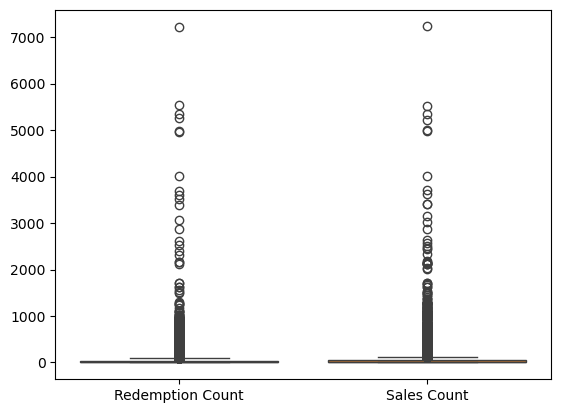

In [67]:

import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=df[['Redemption Count','Sales Count']])
plt.show()

In [68]:
from scipy import stats

df['zscore'] = stats.zscore(df['Redemption Count'])

outliers = df[df['zscore'].abs() > 3]

print(outliers)

           _id           Timestamp  Redemption Count  Sales Count  year  \
1027      1028 2025-12-04 14:30:00               408          416  2025   
5686      5687 2025-09-28 12:00:00               385          309  2025   
5965      5966 2025-09-24 22:30:00              4020         4015  2025   
6290      6291 2025-09-20 13:15:00               416          299  2025   
6535      6536 2025-09-17 11:15:00               384          344  2025   
...        ...                 ...               ...          ...   ...   
260748  260749 2015-05-17 23:00:00               425            0  2015   
260749  260750 2015-05-17 22:45:00               712            0  2015   
260750  260751 2015-05-17 22:30:00               575            5  2015   
260751  260752 2015-05-17 22:15:00               487           35  2015   
260754  260755 2015-05-17 21:30:00               367            9  2015   

        month  day  hour     zscore  
1027       12    4    14   3.434892  
5686        9   28    1

## Data consistency Check 

In [69]:
df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count', 'year', 'month',
       'day', 'hour', 'zscore'],
      dtype='object')

In [70]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Timestamp'].dtype

dtype('<M8[ns]')

In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 261538 entries, 0 to 261537
Data columns (total 9 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   _id               261538 non-null  int64         
 1   Timestamp         261538 non-null  datetime64[ns]
 2   Redemption Count  261538 non-null  int64         
 3   Sales Count       261538 non-null  int64         
 4   year              261538 non-null  int32         
 5   month             261538 non-null  int32         
 6   day               261538 non-null  int32         
 7   hour              261538 non-null  int32         
 8   zscore            261538 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int32(4), int64(3)
memory usage: 16.0 MB


## Feature Engineering 

### Hours of day 

## Extract the hour from timestamp.

In [72]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df['hour'] = df['Timestamp'].dt.hour
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour,zscore
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22,-0.333671
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22,-0.458015
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22,-0.448450
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21,-0.362366
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21,-0.371931


## Extract the weekday.

In [73]:
df['day_of_week'] = df['Timestamp'].dt.day_name()
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour,zscore,day_of_week
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22,-0.333671,Sunday
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22,-0.458015,Sunday
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22,-0.448450,Sunday
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21,-0.362366,Sunday
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21,-0.371931,Sunday


## Month / Season

In [74]:
df['month'] = df['Timestamp'].dt.month
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour,zscore,day_of_week
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22,-0.333671,Sunday
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22,-0.458015,Sunday
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22,-0.448450,Sunday
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21,-0.362366,Sunday
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21,-0.371931,Sunday


## Weekend vs Weekday

In [75]:
df['weekend'] = df['Timestamp'].dt.weekday >= 5
df.head(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour,zscore,day_of_week,weekend
0,1,2025-12-21 22:30:00,14,16,2025,12,21,22,-0.333671,Sunday,True
1,2,2025-12-21 22:15:00,1,0,2025,12,21,22,-0.458015,Sunday,True
2,3,2025-12-21 22:00:00,2,0,2025,12,21,22,-0.448450,Sunday,True
3,4,2025-12-21 21:30:00,11,1,2025,12,21,21,-0.362366,Sunday,True
4,5,2025-12-21 21:15:00,10,0,2025,12,21,21,-0.371931,Sunday,True


In [76]:
df.tail(5)

,_id,Timestamp,Redemption Count,Sales Count,year,month,day,hour,zscore,day_of_week,weekend
261533,261534,2015-05-04 16:00:00,0,2,2015,5,4,16,-0.467579,Monday,False
261534,261535,2015-05-01 16:00:00,1,0,2015,5,1,16,-0.458015,Friday,False
261535,261536,2015-05-01 15:45:00,0,1,2015,5,1,15,-0.467579,Friday,False
261536,261537,2015-05-01 15:15:00,0,2,2015,5,1,15,-0.467579,Friday,False
261537,261538,2015-05-01 13:30:00,0,1,2015,5,1,13,-0.467579,Friday,False


## Exploratory Data Analysis 

## Hourly and Daily Demand Trends

In [77]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['hour'] = df['Timestamp'].dt.hour

hourly_demand = df.groupby('hour')['Sales Count'].sum()
print(hourly_demand)

hour
0       55357
1       24314
2       11131
3        6734
4        3440
5        5611
6       71790
7      140104
8      352362
9      756876
10    1087669
11    1382050
12    1423362
13    1398298
14    1346528
15    1208209
16    1020424
17     800584
18     583343
19     419508
20     299957
21     238737
22     201737
23     133926
Name: Sales Count, dtype: int64


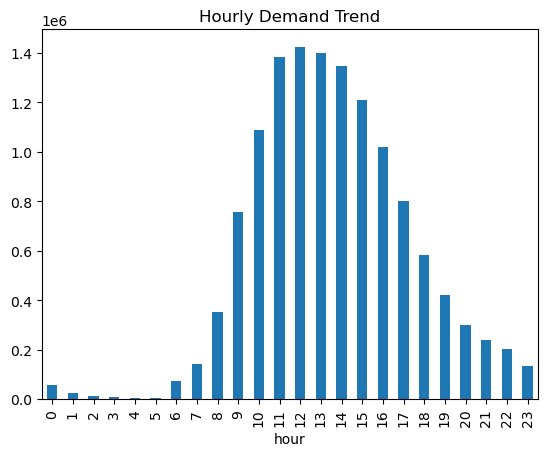

day_of_week
Friday       1784931
Monday       1670609
Saturday     2727394
Sunday       2550994
Thursday     1461639
Tuesday      1331860
Wednesday    1444624
Name: Sales Count, dtype: int64


In [78]:
import matplotlib.pyplot as plt

hourly_demand.plot(kind='bar')
plt.title("Hourly Demand Trend")
plt.show()
## Daily Demand Trends 
daily_demand = df.groupby('day_of_week')['Sales Count'].sum()
print(daily_demand)



## Seasonal Comparison

In [79]:
df['month'] = df['Timestamp'].dt.month

seasonal = df.groupby('month')['Sales Count'].sum()
print(seasonal)

month
1      130455
2      146179
3      201753
4      401395
5     1090751
6     1814395
7     3083858
8     3442762
9     1605867
10     638215
11     254575
12     161846
Name: Sales Count, dtype: int64


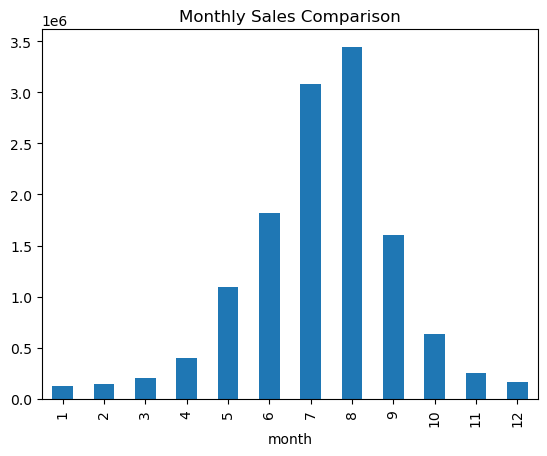

In [80]:
seasonal.plot(kind='bar')
plt.title("Monthly Sales Comparison")
plt.show()

## Sales vs Redemption Distribution

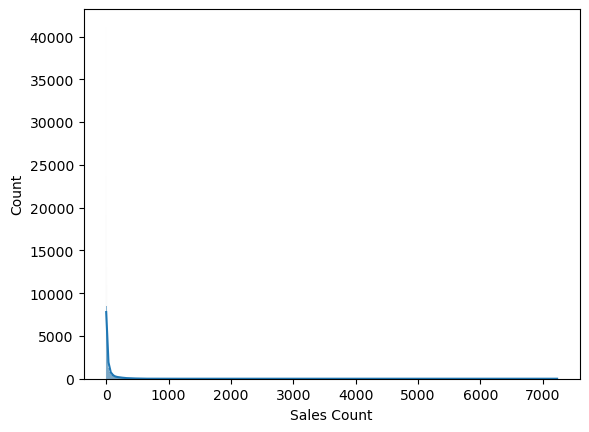

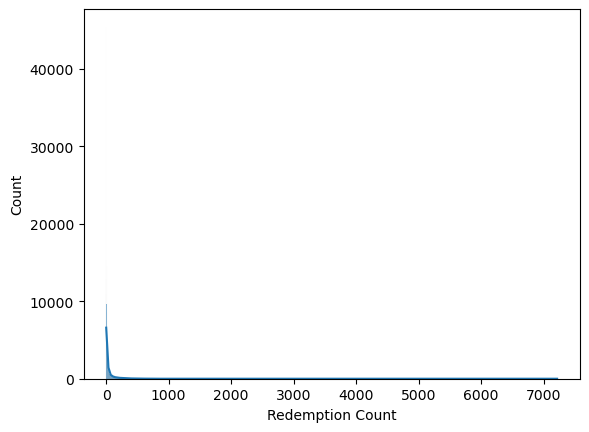

In [81]:
import seaborn as sns

sns.histplot(df['Sales Count'], kde=True)
plt.show()

sns.histplot(df['Redemption Count'], kde=True)
plt.show()

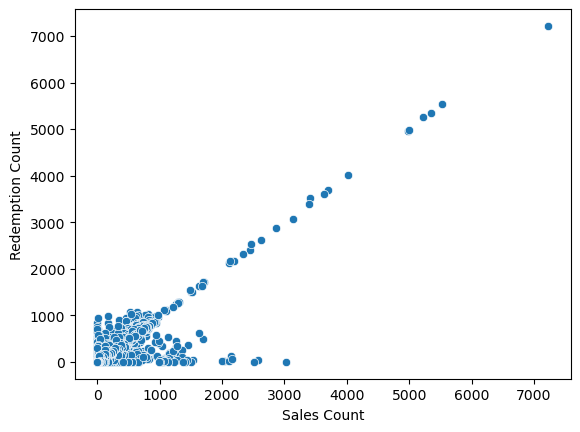

In [82]:
sns.scatterplot(x='Sales Count', y='Redemption Count', data=df)
plt.show()

## Rolling Averages (Time Series Smoothing)

In [83]:
df['sales_rolling_1h'] = df['Sales Count'].rolling(window=1).mean()

In [84]:
df['sales_rolling_4h'] = df['Sales Count'].rolling(window=4).mean()

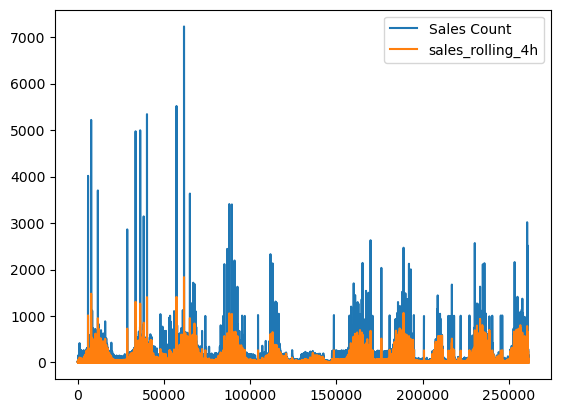

In [85]:
df[['Sales Count','sales_rolling_4h']].plot()
plt.show()